# Writing your own Neural Network code

In [1]:
# Settings for both OLS and FFNN

VERBOSE = True
SAVE_FIGURE = True


## OLS with FFNN

In report 1 we used 1000 iterations for analysis. I report 1 figure 3 MSE and R2 for OLS and Ridge regression versus number of datapoints are shown.

Below is the code for analysis in project 1, where best MSE test value is extracted form testing polynomial degree 1 to 15 with 1000 datapoints in Runge function.

In [2]:
import autograd.numpy as np
from sklearn.model_selection import train_test_split

# custom imports
import source.OLS_functions as OLS_func
from source.runge_preprocessing import TEST_TRAIN_RANDOM_STATE, TEST_SPLIT, x, x_test, y_noise, DATAPOINTS
from source.utils import rescale_predictions

In [3]:
# Settings OLS

VERBOSE_POLY_DEGREE = False

USE_INTERCEPT = True
polynomial_degree = 15

Min OLS MSE train value: 0.10801263558652031
MIN OLS MSE train index: 14
MIN OLS MSE train polynomial degree: 15

Min OLS MSE test value: 0.13585781774599542
MIN OLS MSE test index: 13
MIN OLS MSE test polynomial degree: 14


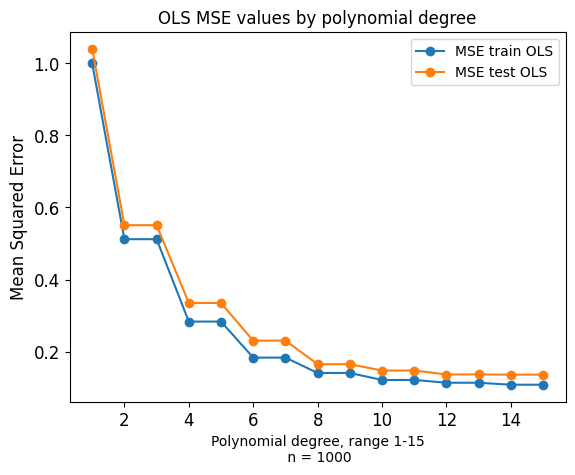

Difference MSE train from polynomial degree 14 and 15: 1.2697794518790051e-05
Difference MSE test from polynomial degree 14 and 15: -0.00021155782067172613


In [4]:
# Code from project 1 to calculate OLS regression


X = OLS_func.polynomial_features(x, polynomial_degree,USE_INTERCEPT)
X_train_ols, X_test_ols, y_train_ols, y_test_ols = train_test_split(X, y_noise, test_size=TEST_SPLIT, random_state=TEST_TRAIN_RANDOM_STATE) 
# Scaleing
X_train_scaled_ols, X_test_scaled_ols, X_train_mean_ols, X_train_std_ols = OLS_func.scale_features_by_intercept_use(X_train_ols, X_test_ols, USE_INTERCEPT)
y_train_scaled_ols, y_test_scaled_ols, y_train_mean_ols, y_train_std_ols = OLS_func.standard_scaler(y_train_ols, y_test_ols)

# Train
theata_scaled = OLS_func.OLS_parameters(X_train_scaled_ols, y_train_scaled_ols)

# Predict
rescaled_theta, rescaled_intercept = OLS_func.rescale_theta_intercept(theata_scaled[1:], theata_scaled[0], y_train_std_ols, y_train_mean_ols, X_train_std_ols, X_train_mean_ols, verbose=VERBOSE_POLY_DEGREE)
y_predicted_scaled_ols = OLS_func.predict_y(X_test_scaled_ols[:, 1:], rescaled_theta)
y_predicted_rescaled_ols = OLS_func.rescale_y(y_predicted_scaled_ols, y_train_std_ols, y_train_mean_ols)
polynomial_degree, mse_train_ols, mse_test_ols, r2_train_ols, r2_test_ols, thetas_ols = OLS_func.explore_polynomial_degree(X_train_scaled_ols, X_test_scaled_ols, y_train_scaled_ols, y_test_scaled_ols, polynomial_degree, USE_INTERCEPT, verbose=VERBOSE_POLY_DEGREE)

# Minimum OLS MSE train and test values
min_mse_train_value_ols = min(mse_train_ols)
min_mse_train_index_ols = mse_train_ols.index(min_mse_train_value_ols)

min_mse_test_value_ols = min(mse_test_ols)
min_mse_test_index_ols = mse_test_ols.index(min_mse_test_value_ols)
if VERBOSE: 
    print(f'Min OLS MSE train value: {min_mse_train_value_ols}\nMIN OLS MSE train index: {min_mse_train_index_ols}\nMIN OLS MSE train polynomial degree: {min_mse_train_index_ols+1}')
    print()
    print(f'Min OLS MSE test value: {min_mse_test_value_ols}\nMIN OLS MSE test index: {min_mse_test_index_ols}\nMIN OLS MSE test polynomial degree: {min_mse_test_index_ols+1}')

if SAVE_FIGURE:
    OLS_func.plot_mse("OLS",DATAPOINTS, polynomial_degree, mse_train_ols, mse_test_ols, f"Polynomial degree, range {polynomial_degree[0]}-{polynomial_degree[-1]}\n n = {DATAPOINTS}",fname='part_b-runge_ols_mse_degree', title='OLS MSE values by polynomial degree' ,save=SAVE_FIGURE)

# Difference mse results polynomial degree 14 and 15
difference_train_mse = mse_train_ols[-2] - mse_train_ols[-1]
difference_test_mse = mse_test_ols[-2] - mse_test_ols[-1]
if VERBOSE: 
    print(f'Difference MSE train from polynomial degree 14 and 15: {difference_train_mse}')
    print(f'Difference MSE test from polynomial degree 14 and 15: {difference_test_mse}')

### Discussion

In project 1 polynomial degree 15 is used for analysis.
The results above show that minimum MSE train value is for polynomial degree 15, and minimum MSE test value is 14.
Then the difference in MSE train and test is shown to be very small. 

Based on this further analysis in part_b use polynomial degree 15.

# Own implementation of Neural Network

Uses the same dataset as for OLS regression above


In [5]:
# imports

from source.utils import decide_activation_func, create_activations_layderdim
from source.runge_preprocessing import NP_RANDOM_SEED, x, y, ETA_VALUES
from source.neural_network import NN
from source.cost_functions import class_mse_loss
from source.plotting import plot_runges_two_predictions, plot_heatmap
from source.utils import neural_network_loop, decide_activation_func


In [6]:
# settings for FFNN

VERBOSE_FFNN = True

act_func_task = 'sigmoid'     # Choose from 'RELU'  'LRELU' 'sigmoid'
ffnn_iterations = 10000
batch_value = 256

cost_fn_ols = class_mse_loss(l1=0, l2=0)   # mse for regression, no penalty for L1 and L2 

# Reshape y created with code from proejct 1
y_train_scaled_ols = np.array(y_train_scaled_ols).reshape(-1, 1)
y_test_scaled_ols = np.array(y_test_scaled_ols).reshape(-1, 1)


LAMBDA_VALUES = [0] #We use lambda = 0 in part_b, only examining learning rate



## 50 and 100 nodes in two hidden layers

In [7]:
# Hidden layers
hidden_50_100 = (50, 100)

# Set up input, hidden, and output layers and dimensions
activaton_func_50_100, activaton_func_derivative_50_100, output_func_50_100, output_func_derivative = decide_activation_func(act_func_task)
activations_50_100, activations_derivative_50_100, _dim_50_100 = create_activations_layderdim(activaton_func_50_100, activaton_func_derivative_50_100, 
                                                                         output_func_50_100, output_func_derivative, 
                                                                         hidden_50_100, y_train_scaled_ols, X_train_scaled_ols)

def model_50_100_fn():
    return NN(_dim_50_100, activations_50_100, activations_derivative_50_100, cost_fn_ols, NP_RANDOM_SEED)


if VERBOSE:
    print(f'Activation layers: {activations_50_100}\nand their derivatives: {activations_derivative_50_100}\nDimensions if input, hidden layers and output layer: {_dim_50_100}')


Activation layers: [<function sigmoid at 0x0000028A22E1ADE0>, <function sigmoid at 0x0000028A22E1ADE0>, <function linear at 0x0000028A22E1B1A0>]
and their derivatives: [<function sigmoid_derivative at 0x0000028A22E1AE80>, <function sigmoid_derivative at 0x0000028A22E1AE80>, <function linear_derivative at 0x0000028A22E1B240>]
Dimensions if input, hidden layers and output layer: [16, 50, 100, 1]


In [ ]:
# Loop through learning rate (ETA_VALUES) to evaluvate MSE


# Plain SGD
momentum_val = 0
plain_SGD_results_50_100 = neural_network_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, 
                                               X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, momentum=momentum_val, verbose=VERBOSE_FFNN) 

# SGD with momentum --- NOT mentioned in project 2 description
#momentum_val = 0.9
#NN_50_100.reset_weights() # reset weights such that previous runs or reruns don't affect the weights
#SGD_results_50_100 = neural_network_loop(NN_50_100, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, momentum=momentum_val, verbose=VERBOSE_FFNN) 

# RMSProp with momentum
rho_val = 0.9
RMSporp_results_50_100 = neural_network_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, verbose=VERBOSE_FFNN) 

# ADAM
rho_val = 0.9
rho2_val = 0.999
ADAM_results_50_100 = neural_network_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, verbose=VERBOSE_FFNN) 




Training with optimizer=SGD, lr=0.1, lambda=0, iterations=10000
L1: 0 L2: 0
Using scheduler: momentum 


c:\Users\brumor\python_env\4155\.venv\Lib\site-packages\autograd\tracer.py:54: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:277: RuntimeWarning: overflow encountered in matmul
  dC_da = dC_dz @ W.T
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:280: RuntimeWarning: invalid value encountered in multiply
  dC_dz = dC_da * activation_der(z)


In [ ]:
if SAVE_FIGURE:

    task = 'part_b'
    hidden_str = 'hidden50-100'
    algo = 'ownNN'
    plot_type = 'heatmap'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_value}-{algo}'

    plot_heatmap(plain_SGD_results_50_100, 'MSE test', title='Heatmap with MSE values for plain SGD\n50 and 100 nodes in two hidden layers', filename = 'plain-sgd_' + filename_values)
    plot_heatmap(RMSporp_results_50_100, 'MSE test', title='Heatmap with MSE values for RMSprop\n50 and 100 nodes in two hidden layers', filename = 'rmsprop_' + filename_values)
    plot_heatmap(ADAM_results_50_100, 'MSE test', title='Heatmap with MSE values for ADAM\n50 and 100 nodes in two hidden layers', filename = 'adam_' + filename_values)


In [ ]:
# Rescale predictions for best MSE

predictions_rescaled_plain_SGD_results_50_100 = rescale_predictions(plain_SGD_results_50_100, y_train_std_ols, y_train_mean_ols)
predictions_rescaled_RMSporp_results_50_100 = rescale_predictions(RMSporp_results_50_100, y_train_std_ols, y_train_mean_ols)
predictions_rescaled_ADAM_results_50_100 = rescale_predictions(ADAM_results_50_100, y_train_std_ols, y_train_mean_ols)



In [ ]:
# Plot Runges with predicted OLS and FFNN, latter based on best MSE test value

if SAVE_FIGURE:
    # Plotting Runge function and predictions from OLS regression and FFNN

    task = 'part_b'
    hidden_str = 'hidden50-100'
    algo = 'ownNN'
    plot_type = 'runges'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_value}-{algo}'


    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, predictions_rescaled_plain_SGD_results_50_100, 
                                                            label_scatter1='OLS predictions', label_scatter2='Plain SGD predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and Plain SGD predictions\n50 and 100 nodes in two hidden layers',
                                                            filename='plain-sgd_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)
                                                            
    
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, predictions_rescaled_RMSporp_results_50_100, 
                                                            label_scatter1='OLS predictions', label_scatter2='RMSprop predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 and 100 nodes in two hidden layers',
                                                            filename='rmsprop_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, predictions_rescaled_ADAM_results_50_100, 
                                                            label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 and 100 nodes in two hidden layers',
                                                            filename='adam_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

## 50 nodes in one hidden layers

In [ ]:
# Hidden layers
hidden_50 = (50,)

# Set up input, hidden, and output layers and dimensions
activaton_func_50, activaton_func_derivative_50, output_func_50, output_func_derivative = decide_activation_func(act_func_task)
activations_50, activations_derivative_50, _dim_50 = create_activations_layderdim(activaton_func_50, activaton_func_derivative_50, 
                                                                         output_func_50, output_func_derivative, 
                                                                         hidden_50, y_train_scaled_ols, X_train_scaled_ols)

def model_50_fn():
    return NN(_dim_50, activations_50, activations_derivative_50, cost_fn_ols, NP_RANDOM_SEED)

if VERBOSE:
    print(f'Activation layers: {activations_50}\nand their derivatives: {activations_derivative_50}\nDimensions if input, hidden layers and output layer: {_dim_50}')


In [ ]:
# Loop through learning rate (ETA_VALUES) to evaluvate MSE


# Plain SGD
momentum_val = 0
plain_SGD_results_50 = neural_network_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, 
                                               X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, momentum=momentum_val, verbose=VERBOSE_FFNN) 

# SGD with momentum --- NOT mentioned in project 2 description
#momentum_val = 0.9
#SGD_results_50 = neural_network_loop(NN_50, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, momentum=momentum_val, verbose=VERBOSE_FFNN) 

# RMSProp with momentum
rho_val = 0.9
RMSporp_results_50 = neural_network_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, verbose=VERBOSE_FFNN) 

# ADAM
rho_val = 0.9
rho2_val = 0.999
ADAM_results_50 = neural_network_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, verbose=VERBOSE_FFNN) 



In [ ]:
if SAVE_FIGURE:

    task = 'part_b'
    hidden_str = 'hidden50'
    algo = 'own'
    plot_type = 'heatmap'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_value}-{algo}'

    plot_heatmap(plain_SGD_results_50, 'MSE test', title='Heatmap with MSE values for plain SGD\n50 nodes in one hidden layer', filename='plain-sgd_' + filename_values)
    plot_heatmap(RMSporp_results_50, 'MSE test', title='Heatmap with MSE values for RMSprop\n50 nodes in one hidden layer', filename='rmsprop_' + filename_values)
    plot_heatmap(ADAM_results_50, 'MSE test', title='Heatmap with MSE values for ADAM\n50 nodes in one hidden layer', filename='adam_' + filename_values)


In [ ]:
# Rescale predictions for best MSE

predictions_rescaled_plain_SGD_results_50 = rescale_predictions(plain_SGD_results_50, y_train_std_ols, y_train_mean_ols)
predictions_rescaled_RMSporp_results_50 = rescale_predictions(RMSporp_results_50, y_train_std_ols, y_train_mean_ols)
predictions_rescaled_ADAM_results_50 = rescale_predictions(ADAM_results_50, y_train_std_ols, y_train_mean_ols)


In [ ]:
# Plot Runges with predicted OLS and FFNN, latter based on best MSE test value

if SAVE_FIGURE:
    # Plotting Runge function and predictions from OLS regression and FFNN

    task = 'part_b'
    hidden_str = 'hidden50'
    algo = 'ownNN'
    plot_type = 'runge'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_value}-{algo}'

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, predictions_rescaled_plain_SGD_results_50, 
                                                            label_scatter1='OLS predictions', label_scatter2='Plain SGD predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and Plain SGD predictions\n50 nodes in one hidden layers',
                                                            filename='plain-sgd_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)
                                                            
    
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, predictions_rescaled_RMSporp_results_50, 
                                                            label_scatter1='OLS predictions', label_scatter2='RMSprop predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 nodes in one hidden layers',
                                                            filename='rmsprop_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, predictions_rescaled_ADAM_results_50, 
                                                            label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 nodes in one hidden layers',
                                                            filename='adam_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)